# 01 · M1 Random Forest (wavelet + statistical + RR features)

**Owner:** Tanishq Sharma  
Classical machine-learning baseline. Script: `src/models/m1_random_forest.py`.

In [1]:
# Setup: works locally (run from notebooks/) and on Google Colab.
# On Colab, first clone the team repository and install the requirements:
#   !git clone <repo-url> ecg-arrhythmia && %cd ecg-arrhythmia/notebooks
#   !pip install -q -r ../requirements.txt
import os, sys, json
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = os.path.abspath('..')
sys.path[:0] = [os.path.join(ROOT, 'src'), os.path.join(ROOT, 'src', 'models')]
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman', 'DejaVu Serif']})
%matplotlib inline

In [2]:
from m1_random_forest import load_features, featurise, build, CONFIG
from evaluate import score, search_f1
from config import CLASSES, SEEDS
data, names = load_features()
(Atr, ytr), (Ava, yva), (Ate, yte) = data["train"], data["val"], data["test"]
print(Atr.shape[1], "features per beat"); print(names)

55 features per beat
['cA4_0', 'cA4_1', 'cA4_2', 'cA4_3', 'cA4_4', 'cA4_5', 'cA4_6', 'cA4_7', 'cA4_8', 'cA4_9', 'cA4_10', 'cA4_11', 'cA4_12', 'cA4_13', 'cA4_14', 'cA4_15', 'cA4_16', 'cA4_17', 'cA4_18', 'cA4_19', 'cA4_20', 'cA4_21', 'cA4_22', 'cA4_23', 'cA4_24', 'cA4_25', 'cA4_26', 'cA4_27', 'cA4_28', 'cD4_energy', 'cD4_std', 'cD4_maxabs', 'cD3_energy', 'cD3_std', 'cD3_maxabs', 'cD2_energy', 'cD2_std', 'cD2_maxabs', 'cD1_energy', 'cD1_std', 'cD1_maxabs', 'mean', 'std', 'min', 'max', 'median', 'iqr', 'energy', 'skewness', 'kurtosis', 'zero_cross_rate', 'pre_RR', 'post_RR', 'local_RR', 'RR_ratio']


## Why no N-undersampling? (decided on validation only)
Undersampling the majority class is a common fix for imbalance. We checked it on the patient-held-out validation split before fixing the configuration. Using the full training set gave the best validation macro-F1, so the final model uses it with `class_weight="balanced_subsample"`.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score
rng = np.random.default_rng(42); nidx = np.flatnonzero(ytr == 0)
for cap in [None, 10000, 5000]:
    keep = np.arange(len(ytr)) if cap is None else np.sort(np.concatenate([np.flatnonzero(ytr != 0), rng.choice(nidx, cap, replace=False)]))
    for leaf in [2, 10]:
        m = RandomForestClassifier(300, min_samples_leaf=leaf, max_features="sqrt", class_weight="balanced_subsample", n_jobs=-1, random_state=42).fit(Atr[keep], ytr[keep])
        p = m.predict(Ava)
        print(f"N cap {str(cap):>6}  leaf {leaf:2d}  val macro-F1(NSVF) {search_f1(yva, p):.4f}  recall N/S/V/F", np.round(recall_score(yva, p, labels=[0,1,2,3], average=None, zero_division=0), 3))

N cap   None  leaf  2  val macro-F1(NSVF) 0.3869  recall N/S/V/F [0.977 0.    0.57  0.   ]


N cap   None  leaf 10  val macro-F1(NSVF) 0.3355  recall N/S/V/F [0.847 0.009 0.802 0.   ]


N cap  10000  leaf  2  val macro-F1(NSVF) 0.3276  recall N/S/V/F [0.849 0.    0.763 0.   ]


N cap  10000  leaf 10  val macro-F1(NSVF) 0.3553  recall N/S/V/F [0.819 0.07  0.868 0.   ]


N cap   5000  leaf  2  val macro-F1(NSVF) 0.3395  recall N/S/V/F [0.825 0.022 0.877 0.   ]


N cap   5000  leaf 10  val macro-F1(NSVF) 0.3658  recall N/S/V/F [0.814 0.097 0.885 0.   ]


## Final model, seed 42 retrained here, compared with the saved result

In [4]:
model = build(42).fit(Atr, ytr)
m = score(yte, model.predict(Ate))
saved = json.load(open(os.path.join(ROOT, "results", "runs", "m1_random_forest_seed42.json")))
print(f"macro-F1 here {m['macro_f1']:.4f}   saved {saved['macro_f1']:.4f}")

macro-F1 here 0.3690   saved 0.3690


DS2 macro-F1 0.3707 +/- 0.0012 (N/S/V/F: 0.4633 +/- 0.0015)
class   recall           F1
  N    0.998 ± 0.000    0.967 ± 0.000   (n=44228)
  S    0.014 ± 0.001    0.027 ± 0.002   (n=1836)
  V    0.779 ± 0.004    0.859 ± 0.004   (n=3220)
  F    0.000 ± 0.000    0.000 ± 0.000   (n=388)
  Q    0.000 ± 0.000    0.000 ± 0.000   (n=7)


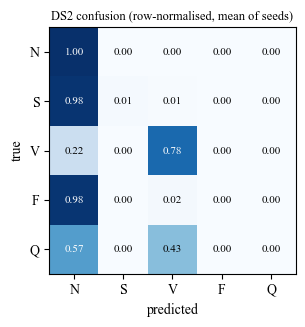

In [5]:
TAG = 'm1_random_forest'
with open(os.path.join(ROOT, 'results', f'{TAG}.json')) as fh:
    agg = json.load(fh)
print(f"DS2 macro-F1 {agg['macro_f1']['mean']:.4f} +/- {agg['macro_f1']['std']:.4f} "
      f"(N/S/V/F: {agg['macro_f1_nsvf']['mean']:.4f} +/- {agg['macro_f1_nsvf']['std']:.4f})")
print('class   recall           F1')
for c in CLASSES:
    r, f = agg['per_class_recall'][c], agg['per_class_f1'][c]
    print(f"  {c}    {r['mean']:.3f} ± {r['std']:.3f}    {f['mean']:.3f} ± {f['std']:.3f}   (n={agg['support'][c]})")
cm = np.array(agg['confusion_matrix_sum']) / len(agg['seeds'])
norm = cm / np.maximum(cm.sum(1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.imshow(norm, cmap='Blues', vmin=0, vmax=1)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{norm[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if norm[i,j] > .55 else 'black')
ax.set_xticks(range(5), CLASSES); ax.set_yticks(range(5), CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('DS2 confusion (row-normalised, mean of seeds)', fontsize=9)
plt.show()

## Feature importance (mean decrease in impurity, averaged over seeds)

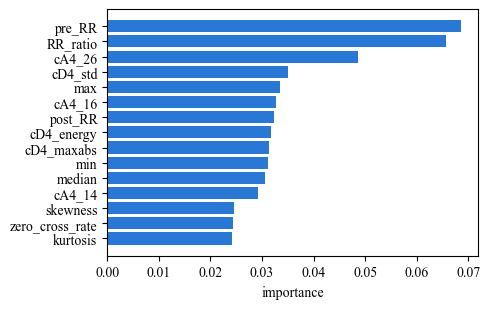

In [6]:
imp = json.load(open(os.path.join(ROOT, "results", "m1_feature_importance.json")))[:15]
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.barh([e["feature"] for e in imp][::-1], [e["importance"] for e in imp][::-1], color="#2a78d6")
ax.set_xlabel("importance"); plt.tight_layout(); plt.show()

**Reading:** the RR features (pre-RR, RR ratio) rank highest, yet S recall on unseen DS2 patients stays near zero. The forest learns the absolute RR ranges of the 16 training patients; on new patients with different resting heart rates these thresholds do not transfer. This is the inter-patient generalisation gap the project studies.

# Final phase: grouped cross-validation and final model

The Random Forest kept both changes: patient-relative RR features and SMOTE oversampling of S/V/F in the training data.

In [7]:
TAG, INTERIM_TAG = 'm1_random_forest', 'm1_random_forest'
sel = json.load(open(os.path.join(ROOT, 'results', 'final', TAG, 'selected.json')))
print('selected variant:', sel['variant'], '| epochs:', sel['epochs'])
print('config:', sel['config'])
print('calibration offsets (N,S,V,F,Q):', [round(v, 2) for v in sel['offsets']])
print('\nablation under 4-fold grouped CV on DS1 (macro-F1 over N/S/V/F):')
for l in sel['ablation_log']:
    print(f"  {l['step']:10s} {l['cv_macro_f1_nsvf']:.4f}  {'kept' if l['kept'] else 'rejected'}")

selected variant: baseline+relRR+smote | epochs: None
config: {'rel_rr': True, 'smote': True}
calibration offsets (N,S,V,F,Q): [0.0, 0.75, 0.0, 1.25, 0.0]

ablation under 4-fold grouped CV on DS1 (macro-F1 over N/S/V/F):
  baseline   0.4293  kept
  relRR      0.4413  kept
  smote      0.4642  kept


### Refit the final model (seed 42) and compare with the stored result

In [8]:
import numpy as np
from m1_random_forest import all_features, fit_rf, proba5
from calibrate import apply as apply_offsets
from evaluate import score
cfg, offsets = sel['config'], np.array(sel['offsets'])
d, names = all_features(bool(cfg.get('rel_rr')))
tr, te = d['split'] != 'test', d['split'] == 'test'
p = proba5(fit_rf(d['A'][tr], d['y'][tr], cfg, 42), d['A'][te])
stored = json.load(open(os.path.join(ROOT, 'results', 'final', 'runs', f'{TAG}_seed42.json')))
cal = score(d['y'][te], apply_offsets(p, offsets))['macro_f1']
print(f"calibrated macro-F1 here {cal:.4f}   stored {stored['calibrated']['macro_f1']:.4f}   match {abs(cal - stored['calibrated']['macro_f1']) < 1e-9}")

calibrated macro-F1 here 0.3973   stored 0.3973   match True


### Interim vs final on DS2 (mean ± std over 3 seeds)

In [9]:
fin = json.load(open(os.path.join(ROOT, 'results', 'final', f'{TAG}.json')))
old = json.load(open(os.path.join(ROOT, 'results', f'{INTERIM_TAG}.json')))
print(f"interim          macro-F1 {old['macro_f1']['mean']:.3f} ± {old['macro_f1']['std']:.3f}")
for kind in ['raw', 'calibrated']:
    r = fin[kind]
    print(f"final {kind:10s} macro-F1 {r['macro_f1']['mean']:.3f} ± {r['macro_f1']['std']:.3f}  | recall "
          + '  '.join(f"{c} {r['per_class_recall'][c]['mean']:.2f}" for c in 'NSVF'))

interim          macro-F1 0.371 ± 0.001
final raw        macro-F1 0.388 ± 0.000  | recall N 0.99  S 0.04  V 0.88  F 0.00
final calibrated macro-F1 0.399 ± 0.001  | recall N 0.92  S 0.10  V 0.87  F 0.11
